In [3]:
import rasterio
import rasterio.mask
import imgaug as ia
from imgaug import augmenters as iaa
import fiona

from core.frame_info import FrameInfo

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os

from PIL import Image
import numpy as np

# shp to tif

In [4]:
def mask(shp,intif, outtif, all_touch = True,crop = False, pad = False):
    with fiona.open(shp,'r') as shapefile:
        shapes = [feature['geometry'] for feature in shapefile]
    if shapes:
        tif = rasterio.open(intif)
        out,_ = rasterio.mask.mask(tif, shapes, all_touched = all_touch ,crop = crop , pad = pad,nodata = -101)
        out = np.where(out > -101,  1, out)
        out = np.where(out == -101, 0, out)
        pro = tif.profile
        with rasterio.open(outtif,'w',**pro) as dst:
            dst.write(out)
    # return out

In [5]:
def read_dir(dir_name, start, end):
    file = os.listdir(dir_name)
    lists = []
    for files in file:
        if files.startswith(start) and files.endswith(end):
            files = os.path.join(dir_name,files)
            lists.append(files)
    return lists

In [27]:
shpdir =  r'K:\china_label_shp'
shp_list = read_dir(shpdir, 'clip','shp')

donedir = r'K:\done'
done = read_dir(donedir,'ndwi','tif' )

len(shp_list)
len(done)

368

498

In [28]:
outdir = r'K:\to_tif\to_tif_china_autu'

for index, item in enumerate(done):
    a = os.path.splitext(os.path.split(item)[1])[0]
    b = 0
    for index2, item2 in enumerate(shp_list):
        if item2.find(a) != -1:
            #相同判断
            b = 0
            filename = os.path.split(item)[1]
            outtif = os.path.join(outdir,filename)
            mask(item2, item, outtif)
            
            break
        b = b+1
    if b == len(shp_list):
        print(item)

K:\done\ndwi1_int8_china_103_2.tif
K:\done\ndwi1_int8_china_107_2.tif
K:\done\ndwi1_int8_china_107_3.tif
K:\done\ndwi1_int8_china_110_3.tif
K:\done\ndwi1_int8_china_121_1.tif
K:\done\ndwi1_int8_china_164_2.tif
K:\done\ndwi1_int8_china_166_1.tif
K:\done\ndwi1_int8_china_170_1.tif
K:\done\ndwi1_int8_china_213_1.tif
K:\done\ndwi1_int8_china_215_2.tif
K:\done\ndwi1_int8_china_215_3.tif
K:\done\ndwi1_int8_china_217_1.tif
K:\done\ndwi1_int8_china_217_2.tif
K:\done\ndwi1_int8_china_217_3.tif
K:\done\ndwi1_int8_china_218_3.tif
K:\done\ndwi1_int8_china_21_2.tif
K:\done\ndwi1_int8_china_222_4.tif
K:\done\ndwi1_int8_china_224_3.tif
K:\done\ndwi1_int8_china_226_1.tif
K:\done\ndwi1_int8_china_226_3.tif
K:\done\ndwi1_int8_china_227_2.tif
K:\done\ndwi1_int8_china_227_3.tif
K:\done\ndwi1_int8_china_242_1.tif
K:\done\ndwi1_int8_china_246_3.tif
K:\done\ndwi1_int8_china_246_4.tif
K:\done\ndwi1_int8_china_248_4.tif
K:\done\ndwi1_int8_china_265_4.tif
K:\done\ndwi1_int8_china_266_2.tif
K:\done\ndwi1_int8_ch

# read into frames

In [6]:
frames = []
donedir = r'K:\done'
totifdir = r'K:\to_tif\to_tif_china_autu'
done = read_dir(donedir,'ndwi','tif' )
totif = read_dir(totifdir, 'ndwi','tif')


In [7]:
len(done)
len(totif)

498

359

In [17]:
frames = []
for index, item in enumerate(done):
    a = os.path.splitext(os.path.split(item)[1])[0]
    b = 0
    for index2, item2 in enumerate(totif):
        if item2.find(a) != -1:
            #相同判断
            b = 0
            ndwi_img = rasterio.open(item)
            ann = rasterio.open(item2)
            read_ndwi = ndwi_img.read()
            read_ndwi = np.transpose(read_ndwi, axes=(1,2,0))
            read_ann  = ann.read()
            read_ann = np.transpose(read_ann, axes=(1,2,0))
            f = FrameInfo(read_ndwi,read_ann)
            frames.append(f)
            
            break
        b = b+1
    if b == len(totif):
        print(item)

K:\done\ndwi1_int8_china_103_2.tif
K:\done\ndwi1_int8_china_107_2.tif
K:\done\ndwi1_int8_china_107_3.tif
K:\done\ndwi1_int8_china_110_3.tif
K:\done\ndwi1_int8_china_121_1.tif
K:\done\ndwi1_int8_china_161_1.tif
K:\done\ndwi1_int8_china_161_2.tif
K:\done\ndwi1_int8_china_162_1.tif
K:\done\ndwi1_int8_china_164_2.tif
K:\done\ndwi1_int8_china_164_3.tif
K:\done\ndwi1_int8_china_165_1.tif
K:\done\ndwi1_int8_china_166_1.tif
K:\done\ndwi1_int8_china_167_1.tif
K:\done\ndwi1_int8_china_168_1.tif
K:\done\ndwi1_int8_china_170_1.tif
K:\done\ndwi1_int8_china_195_1.tif
K:\done\ndwi1_int8_china_213_1.tif
K:\done\ndwi1_int8_china_215_2.tif
K:\done\ndwi1_int8_china_215_3.tif
K:\done\ndwi1_int8_china_217_1.tif
K:\done\ndwi1_int8_china_217_2.tif
K:\done\ndwi1_int8_china_217_3.tif
K:\done\ndwi1_int8_china_218_3.tif
K:\done\ndwi1_int8_china_21_2.tif
K:\done\ndwi1_int8_china_222_4.tif
K:\done\ndwi1_int8_china_224_3.tif
K:\done\ndwi1_int8_china_226_1.tif
K:\done\ndwi1_int8_china_226_3.tif
K:\done\ndwi1_int8_ch

# split data

In [8]:
from core.dataset_generator import DataGenerator
from core.split_frames import split_dataset
import json
from sklearn.model_selection import train_test_split


In [29]:
frames

In [9]:
patch_size = (512,512,2)
patch_dir = 'K:/model/model2/patches{}'.format(patch_size[0])
frames_json = os.path.join('K:/model/model2/patches{}'.format(patch_size[0]),'frames_list.json')

In [12]:
list(range(len(frames)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [19]:
training_frames, validation_frames, testing_frames  = split_dataset(frames, frames_json, patch_dir)

Reading train-test split from file
training_frames [238, 322, 90, 318, 68, 242, 243, 324, 308, 275, 233, 354, 159, 83, 209, 87, 125, 310, 236, 165, 218, 215, 301, 317, 71, 298, 96, 115, 12, 97, 255, 343, 22, 303, 292, 182, 32, 70, 178, 132, 54, 329, 283, 2, 229, 5, 279, 126, 168, 295, 158, 357, 130, 69, 187, 191, 155, 111, 4, 286, 144, 299, 120, 248, 37, 133, 29, 219, 194, 223, 139, 138, 211, 23, 44, 251, 246, 40, 282, 267, 249, 199, 1, 334, 326, 313, 208, 230, 150, 320, 277, 149, 288, 257, 216, 201, 114, 270, 86, 39, 358, 41, 347, 350, 129, 112, 167, 24, 226, 293, 172, 64, 171, 89, 52, 65, 101, 145, 60, 185, 315, 353, 289, 336, 294, 284, 221, 56, 264, 258, 174, 345, 355, 224, 200, 319, 92, 193, 148, 110, 77, 105, 16, 349, 88, 356, 15, 335, 210, 95, 285, 214, 49, 82, 274, 339, 328, 188, 198, 245, 268, 43, 80, 217, 3, 269, 244, 137, 104, 180, 323, 276, 102, 42, 30, 341, 281, 163, 351, 280, 0, 305, 100, 177, 260, 346, 152, 28, 153, 272, 94, 176, 53, 327, 79, 134, 21, 190, 220, 62, 212, 9

In [11]:
input_image_channel = [0]
annotation_channels = [1]
BATCH_SIZE = 8  #BATCH_SIZE (int): Number of patches to generate (sampled independently).选几个感受野
normalize =0.4

In [20]:
train_generator = DataGenerator(input_image_channel, patch_size, training_frames, frames, annotation_channels, augmenter = 'iaa').random_generator(BATCH_SIZE, normalize = normalize)
val_generator = DataGenerator(input_image_channel, patch_size, validation_frames, frames, annotation_channels, augmenter= None).random_generator(BATCH_SIZE, normalize = normalize)
test_generator = DataGenerator(input_image_channel, patch_size, testing_frames, frames, annotation_channels, augmenter= None).random_generator(BATCH_SIZE, normalize = normalize)

In [21]:
frames[0].annotations.shape

(1003, 1002, 1)

In [22]:
train_images, real_label = next(train_generator)

In [ ]:

for _ in range(1):
    train_images, real_label = next(train_generator)
    ann = real_label[:,:,0]
    #wei = real_label[:,:,:,1]
    #overlay of annotation with boundary to check the accuracy
    #5 images in each row are: pan, ndvi, annotation, weight(boundary), overlay of annotation with weight
    overlay = ann + wei
    overlay = overlay[:,:,np.newaxis]
    #display_images(np.concatenate((train_images,real_label, overlay), axis = -1))

In [23]:
import time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import imageio
import rasterio.warp             # Reproject raster samples
from functools import reduce
from tensorflow.keras.models import load_model
from core.UNet import UNet
from core.losses import tversky, accuracy, dice_coef, dice_loss, specificity, sensitivity, miou
from core.optimizers import adaDelta, adagrad, adam, nadam
import json

In [24]:
model_path_dir = r'K:\model\model2'
input_shape = (512,512,1)
input_label_channel = [1]


In [25]:
OPTIMIZER = adaDelta
LOSS = tversky 

#Only for the name of the model in the very end
OPTIMIZER_NAME = 'AdaDelta'
LOSS_NAME = 'weightmap_tversky'

# Declare the path to the final model
# If you want to retrain an exising model then change the cell where model is declared. 
# This path is for storing a model after training.

timestr = time.strftime("%Y%m%d-%H%M")
#chf = config.input_image_channel + config.input_label_channel
chf = [0,1]
chs = reduce(lambda a,b: a+str(b), chf, '')


if not os.path.exists(model_path_dir):
    os.makedirs(model_path_dir)
model_path = os.path.join(model_path_dir,'trees_{}_{}_{}_{}_{}.h5'.format(timestr,OPTIMIZER_NAME,LOSS_NAME,chs,input_shape[0]))

# The weights without the model architecture can also be saved. Just saving the weights is more efficent.

# weight_path="./saved_weights/UNet/{}/".format(timestr)
# if not os.path.exists(weight_path):
#     os.makedirs(weight_path)
# weight_path=weight_path + "{}_weights.best.hdf5".format('UNet_model')
# print(weight_path)

In [26]:
chs

'01'

In [27]:
# Define the model and compile it
model = UNet([BATCH_SIZE, *input_shape],input_label_channel)
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[dice_coef, dice_loss, specificity, sensitivity, accuracy,miou])

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Input (InputLayer)              [(None, 512, 512, 1) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 512, 512, 64) 640         Input[0][0]                      
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 512, 512, 64) 36928       conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 512, 512, 64) 256         conv2d_1[0][0]                   
______________________________________________________________________________________________

In [28]:
# Define callbacks for the early stopping of training, LearningRateScheduler and model checkpointing
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard


checkpoint = ModelCheckpoint(model_path, monitor='val_loss', verbose=1, 
                             save_best_only=True, mode='min', save_weights_only = False)

#reduceonplatea; It can be useful when using adam as optimizer
#Reduce learning rate when a metric has stopped improving (after some patience,reduce by a factor of 0.33, new_lr = lr * factor).
#cooldown: number of epochs to wait before resuming normal operation after lr has been reduced.
reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.33,
                                   patience=4, verbose=1, mode='min',
                                   min_delta=0.0001, cooldown=4, min_lr=1e-16)

#early = EarlyStopping(monitor="val_loss", mode="min", verbose=2, patience=15)

log_dir = os.path.join(model_path_dir,'logs/UNet_{}_{}_{}_{}_{}'.format(timestr,OPTIMIZER_NAME,LOSS_NAME,chs, input_shape[0]))
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=0, write_graph=True, write_grads=False, write_images=False, embeddings_freq=0, embeddings_layer_names=None, embeddings_metadata=None, embeddings_data=None, update_freq='epoch')

callbacks_list = [checkpoint, tensorboard] #reduceLROnPlat is not required with adaDelta

In [29]:
callbacks_list[0]

In [30]:
MAX_TRAIN_STEPS = 1000
VALID_IMG_COUNT = 200
NB_EPOCHS = 100

In [ ]:
loss_history = [model.fit(train_generator, 
                         steps_per_epoch=MAX_TRAIN_STEPS, 
                         epochs=NB_EPOCHS, 
                         validation_data=val_generator,
                         validation_steps=VALID_IMG_COUNT,
                         callbacks=callbacks_list,
                         workers=1,
#                         use_multiprocessing=True # the generator is not very thread safe
                        )]

Epoch 1/100
1000/1000 [==============================] - 872s 858ms/step - loss: 0.3704 - dice_coef: 0.7028 - dice_loss: 0.2972 - specificity: 0.9721 - sensitivity: 0.6573 - accuracy: 0.9483 - miou: 0.5189 - val_loss: 0.4491 - val_dice_coef: 0.9494 - val_dice_loss: 0.0506 - val_specificity: 0.9878 - val_sensitivity: 0.4748 - val_accuracy: 0.9605 - val_miou: 0.6092

Epoch 00001: val_loss improved from inf to 0.44914, saving model to K:\model\model2\trees_20221109-2014_AdaDelta_weightmap_tversky_01_512.h5
Epoch 2/100
 520/1000 [==============>...............] - ETA: 6:29 - loss: 0.3215 - dice_coef: 0.8547 - dice_loss: 0.1453 - specificity: 0.9786 - sensitivity: 0.6999 - accuracy: 0.9577 - miou: 0.4631

In [7]:
model_path = r"K:\model\model1\trees_20221027-1439_AdaDelta_weightmap_tversky_01_512.h5"

NameError: name 'adaDelta' is not defined

In [24]:
# Load model after training
# If you load a model with different python version, than you may run into a problem: https://github.com/keras-team/keras/issues/9595#issue-303471777

model = load_model(model_path, custom_objects={'tversky': LOSS, 'dice_coef': dice_coef, 'dice_loss':dice_loss, 'accuracy':accuracy , 'specificity': specificity, 'sensitivity':sensitivity}, compile=False)

# In case you want to use multiple GPU you can uncomment the following lines.
# from tensorflow.python.keras.utils import multi_gpu_model
# model = multi_gpu_model(model, gpus=2, cpu_merge=False)

model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[dice_coef, dice_loss, accuracy, specificity, sensitivity])

In [25]:
from core.visualize import display_images

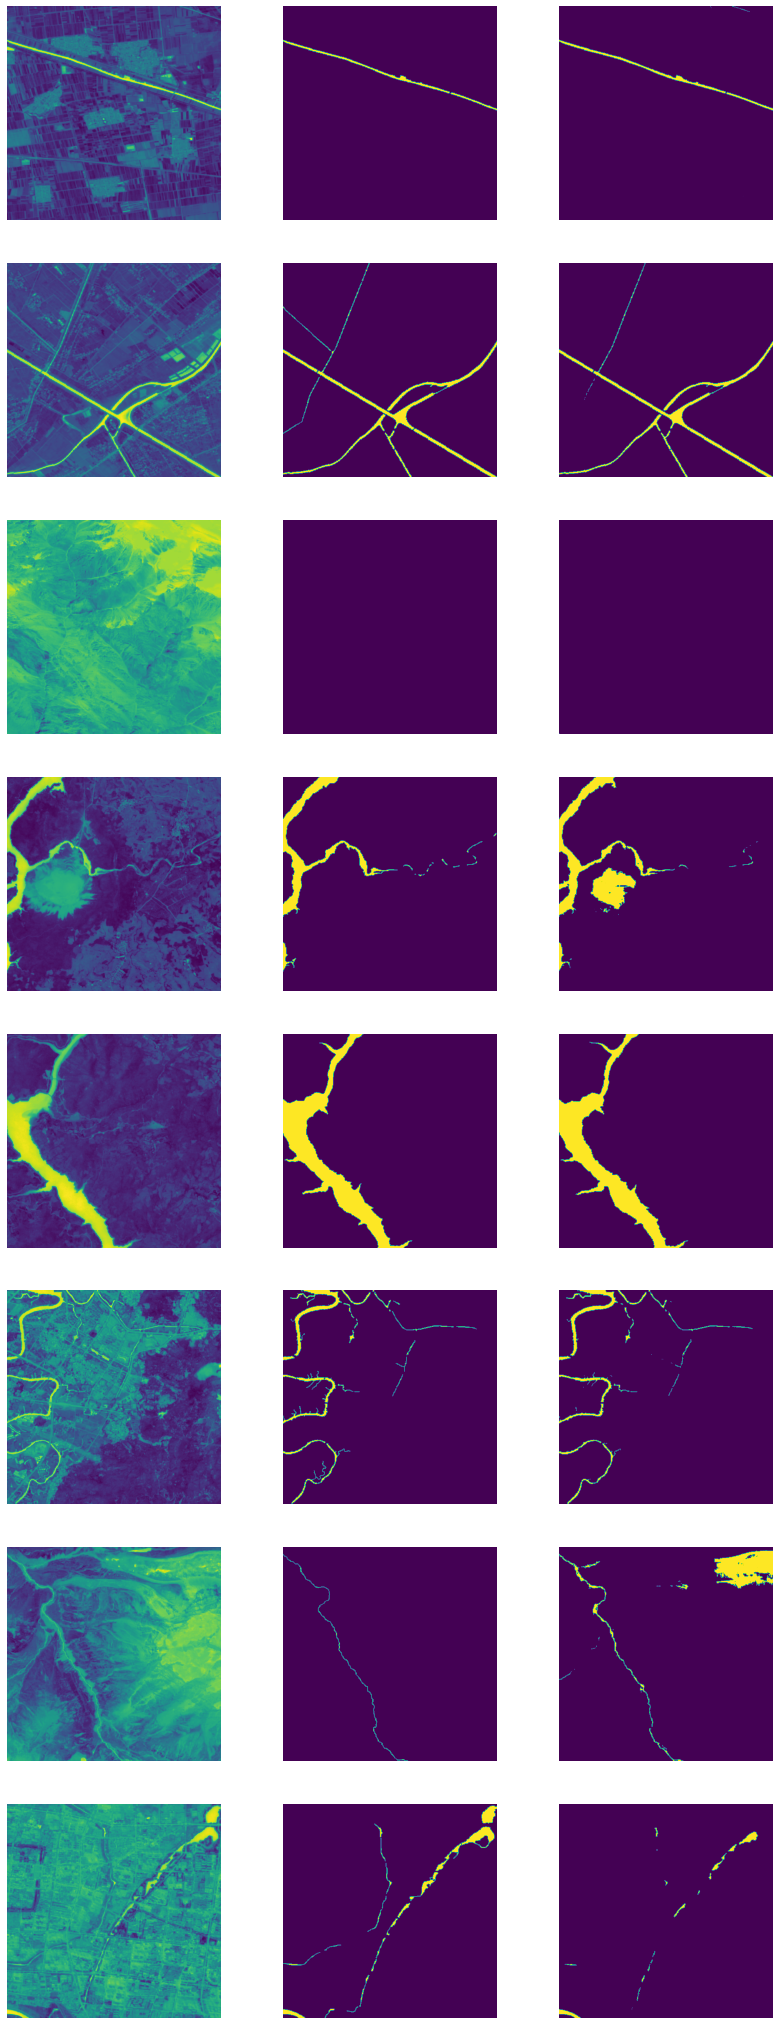

In [32]:
# Print one batch on the training/test data!
for i in range(1):
    test_images, real_label = next(test_generator)
    #5 images per row: pan, ndvi, label, weight, prediction
    prediction = model.predict(test_images, steps=1)
    #prediction[prediction>0.5]=1
    #prediction[prediction<=0.5]=0
    display_images(np.concatenate((test_images, real_label, prediction), axis = -1))
    #prediction[prediction>-10]=1
    #prediction[prediction<=-10]=0
    #display_images(np.concatenate((test_images, real_label, prediction), axis = -1))

In [48]:
test_images.shape

(8, 512, 512, 1)

In [35]:
prediction.shape


(8, 512, 512, 1)

# prediction

In [22]:
from rasterio import windows
from tqdm import tqdm
from itertools import product
from core.frame_info import image_normalize
from tensorflow.keras.models import load_model
from core.UNet import UNet
from core.losses import tversky, accuracy, dice_coef, dice_loss, specificity, sensitivity
from core.optimizers import adaDelta, adagrad, adam, nadam
import json
import os
import rasterio
import numpy as np

In [9]:
model_path = model_path = r"K:\model\model1\trees_20221027-1439_AdaDelta_weightmap_tversky_01_512.h5"
OPTIMIZER = adaDelta
LOSS = tversky 

In [10]:
# Load model after training
# If you load a model with different python version, than you may run into a problem: https://github.com/keras-team/keras/issues/9595#issue-303471777

model = load_model(model_path, custom_objects={'tversky': LOSS, 'dice_coef': dice_coef, 'dice_loss':dice_loss, 'accuracy':accuracy , 'specificity': specificity, 'sensitivity':sensitivity}, compile=False)

# In case you want to use multiple GPU you can uncomment the following lines.
# from tensorflow.python.keras.utils import multi_gpu_model
# model = multi_gpu_model(model, gpus=2, cpu_merge=False)

model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=[dice_coef, dice_loss, accuracy, specificity, sensitivity])

In [12]:
# Methods to add results of a patch to the total results of a larger area. The operator could be min (useful if there are too many false positives), max (useful for tackle false negatives)
def addTOResult(res, prediction, row, col, he, wi, operator = 'MAX'):
    currValue = res[row:row+he, col:col+wi]
    newPredictions = prediction[:he, :wi]
# IMPORTANT: MIN can't be used as long as the mask is initialed with 0!!!!! If you want to use MIN initial the mask with -1 and handle the case of default value(-1) separately.
    if operator == 'MIN': # Takes the min of current prediction and new prediction for each pixel
        currValue [currValue == -1] = 1 #Replace -1 with 1 in case of MIN
        resultant = np.minimum(currValue, newPredictions) 
    elif operator == 'MAX':
        resultant = np.maximum(currValue, newPredictions)
    else: #operator == 'REPLACE':
        resultant = newPredictions    
# Alternative approach; Lets assume that quality of prediction is better in the centre of the image than on the edges
# We use numbers from 1-5 to denote the quality, where 5 is the best and 1 is the worst.In that case, the best result would be to take into quality of prediction based upon position in account
# So for merge with stride of 0.5, for eg. [12345432100000] AND [00000123454321], should be [1234543454321] instead of [1234543214321] that you will currently get. 
# However, in case the values are strecthed before hand this problem will be minimized
    res[row:row+he, col:col+wi] =  resultant
    return (res)

In [11]:
# Methods that actually makes the predictions
def predict_using_model(model, batch, batch_pos, mask, operator):
    tm = np.stack(batch, axis = 0)
    prediction = model.predict(tm)
    for i in range(len(batch_pos)):
        (col, row, wi, he) = batch_pos[i]
        p = np.squeeze(prediction[i], axis = -1)
        # Instead of replacing the current values with new values, use the user specified operator (MIN,MAX,REPLACE)
        mask = addTOResult(mask, p, row, col, he, wi, operator)
    return mask
    

def detect_tree(ndvi_img, width=512, height=512, stride = 256, normalize=True):
    #assert ndvi_img.meta['width'] == pan_img.meta['width'] and ndvi_img.meta['height'] == pan_img.meta['height']
    nols, nrows = ndvi_img.meta['width'], ndvi_img.meta['height']
    meta = ndvi_img.meta.copy()
#    if 'float' not in meta['dtype']: #The prediction is a float so we keep it as float to be consistent with the prediction. 
#        meta['dtype'] = np.float32
    offsets = product(range(0, nols, stride), range(0, nrows, stride))
    big_window = windows.Window(col_off=0, row_off=0, width=nols, height=nrows)
#     print(nrows, nols)

    mask = np.zeros((nrows, nols), dtype=meta['dtype'])

#     mask = mask -1 # Note: The initial mask is initialized with -1 instead of zero to handle the MIN case (see addToResult)
    batch = []
    batch_pos = [ ]
    for col_off, row_off in  tqdm(offsets):
        window =windows.Window(col_off=col_off, row_off=row_off, width=width, height=height).intersection(big_window)
        transform = windows.transform(window, ndvi_img.transform)
        #patch = np.zeros((height, width, 2)) #Add zero padding in case of corner images
        patch = np.zeros((height, width)) 
        ndvi_sm = ndvi_img.read(window=window)
        #pan_sm = pan_img.read(window=window)
        #temp_im = np.stack((ndvi_sm, pan_sm), axis = -1)
        temp_im = np.squeeze(ndvi_sm)
        
        if normalize:
            temp_im = image_normalize(temp_im, axis=(0,1)) # Normalize the image along the width and height i.e. independently per channel
            
        patch[:window.height, :window.width] = temp_im
        batch.append(patch)
        batch_pos.append((window.col_off, window.row_off, window.width, window.height))
        if (len(batch) == BATCH_SIZE):
            mask = predict_using_model(model, batch, batch_pos, mask, 'MAX')
            batch = []
            batch_pos = []
            
    # To handle the edge of images as the image size may not be divisible by n complete batches and few frames on the edge may be left.
    if batch:
        mask = predict_using_model(model, batch, batch_pos, mask, 'MAX')
        batch = []
        batch_pos = []

    return(mask, meta)

In [13]:
def writeMaskToDisk(detected_mask, detected_meta, wp, write_as_type = 'uint8', th = 0.5, create_countors = False):
    # Convert to correct required before writing
    if 'float' in str(detected_meta['dtype']) and 'int' in write_as_type:
        print(f'Converting prediction from {detected_meta["dtype"]} to {write_as_type}, using threshold of {th}')
        detected_mask[detected_mask<th]=0
        detected_mask[detected_mask>=th]=1
        detected_mask = detected_mask.astype(write_as_type)
        detected_meta['dtype'] =  write_as_type
        
    with rasterio.open(wp, 'w', **detected_meta) as outds:
        
        outds.write(detected_mask, 1)
    if create_countors:
        wp = wp.replace(image_type, output_shapefile_type)
        create_contours_shapefile(detected_mask, detected_meta, wp)

In [ ]:
# Predict trees in the all the files in the input image dir
# Depending upon the available RAM, images may not to be split before running this cell.
# Use the Auxiliary-2-SplitRasterToAnalyse if the images are too big to be analysed in memory.
all_files = []
for root, dirs, files in os.walk(config.input_image_dir):
    for file in files:
        if file.endswith(config.input_image_type) and file.startswith(config.ndvi_fn_st):
             all_files.append((os.path.join(root, file), file))
# print(all_files)
for fullPath, filename in all_files:
    outputFile = os.path.join(config.output_dir, filename.replace(config.ndvi_fn_st, config.output_prefix) )
    if not os.path.isfile(outputFile) or config.overwrite_analysed_files: 
        with rasterio.open(fullPath) as ndvi:
            with rasterio.open(fullPath.replace(config.ndvi_fn_st, config.pan_fn_st)) as pan:
                print(fullPath)
                detectedMask, detectedMeta = detect_tree(ndvi, pan, width = config.WIDTH, height = config.HEIGHT, stride = config.STRIDE) # WIDTH and HEIGHT should be the same and in this case Stride is 50 % width
                #Write the mask to file
                writeMaskToDisk(detectedMask, detectedMeta, outputFile, write_as_type = config.output_dtype, th = 0.5, create_countors = False)                
    else:
        print('File already analysed!', fullPath)

In [14]:
input_shape = (512,512,1)
input_label_channel = [1]

In [15]:
WIDTH = input_shape[0]
HEIGHT = input_shape[1]
overlapP = 0.5
STRIDE = int(WIDTH * overlapP)
STRIDE

256

In [18]:
test_dir = r'K:\test\out'
done = read_dir(test_dir, 'ndwi', 'tif')

In [23]:
WIDTH = input_shape[0]
HEIGHT = input_shape[1]
overlapP = 0.5
STRIDE = int(WIDTH * overlapP)
output_dtype = 'uint8'
BATCH_SIZE = 100
outputdir = r"K:\test\pred" 
for index, item in enumerate(done):
    outputFile = os.path.join(outputdir, os.path.split(item)[1])
    with rasterio.open(item) as ndvi:
        detectedMask, detectedMeta = detect_tree(ndvi, width = WIDTH, height = HEIGHT, stride = STRIDE)
        writeMaskToDisk(detectedMask, detectedMeta, outputFile, write_as_type = output_dtype, th = 0.5, create_countors = False)

100it [00:26,  3.71it/s]
100it [00:02, 47.59it/s]
100it [00:02, 46.87it/s]
100it [00:02, 46.81it/s]
100it [00:02, 47.79it/s]
80it [00:00, 350.80it/s]
100it [00:02, 47.32it/s]
100it [00:02, 47.52it/s]
90it [00:00, 324.84it/s]
100it [00:02, 47.36it/s]
100it [00:02, 47.95it/s]
100it [00:02, 46.81it/s]
100it [00:02, 47.00it/s]
100it [00:02, 47.84it/s]
100it [00:02, 47.29it/s]
100it [00:02, 47.07it/s]
100it [00:02, 47.24it/s]
100it [00:02, 47.42it/s]
100it [00:02, 47.32it/s]
100it [00:02, 46.80it/s]
90it [00:00, 333.26it/s]
100it [00:02, 45.82it/s]
100it [00:02, 47.16it/s]
100it [00:02, 47.52it/s]
100it [00:02, 46.50it/s]
100it [00:02, 46.92it/s]
90it [00:00, 323.62it/s]
100it [00:02, 46.09it/s]
35it [00:00, 368.34it/s]
100it [00:02, 46.75it/s]
100it [00:02, 46.59it/s]
35it [00:00, 372.30it/s]
80it [00:00, 327.79it/s]
100it [00:02, 47.34it/s]
100it [00:02, 46.46it/s]
90it [00:00, 296.97it/s]
100it [00:02, 46.54it/s]
100it [00:02, 47.16it/s]
50it [00:00, 324.60it/s]
50it [00:00, 354.40it/s]


In [ ]:
p = 1
p